#Ridge Plot Continous Bayesian Model


PROCESSING: Non-Immune (Continuous BMI Model)
Creating BMI slope ridge plot: Non-Immune
Saved: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_nonimmune/continuous_advanced_diagnostics/overlapped_per_cell/bmi_slope_per_cell_Non-Immune.png
Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/overlapped_per_cell/nonimmune/bmi_slope_per_cell_Non-Immune.svg


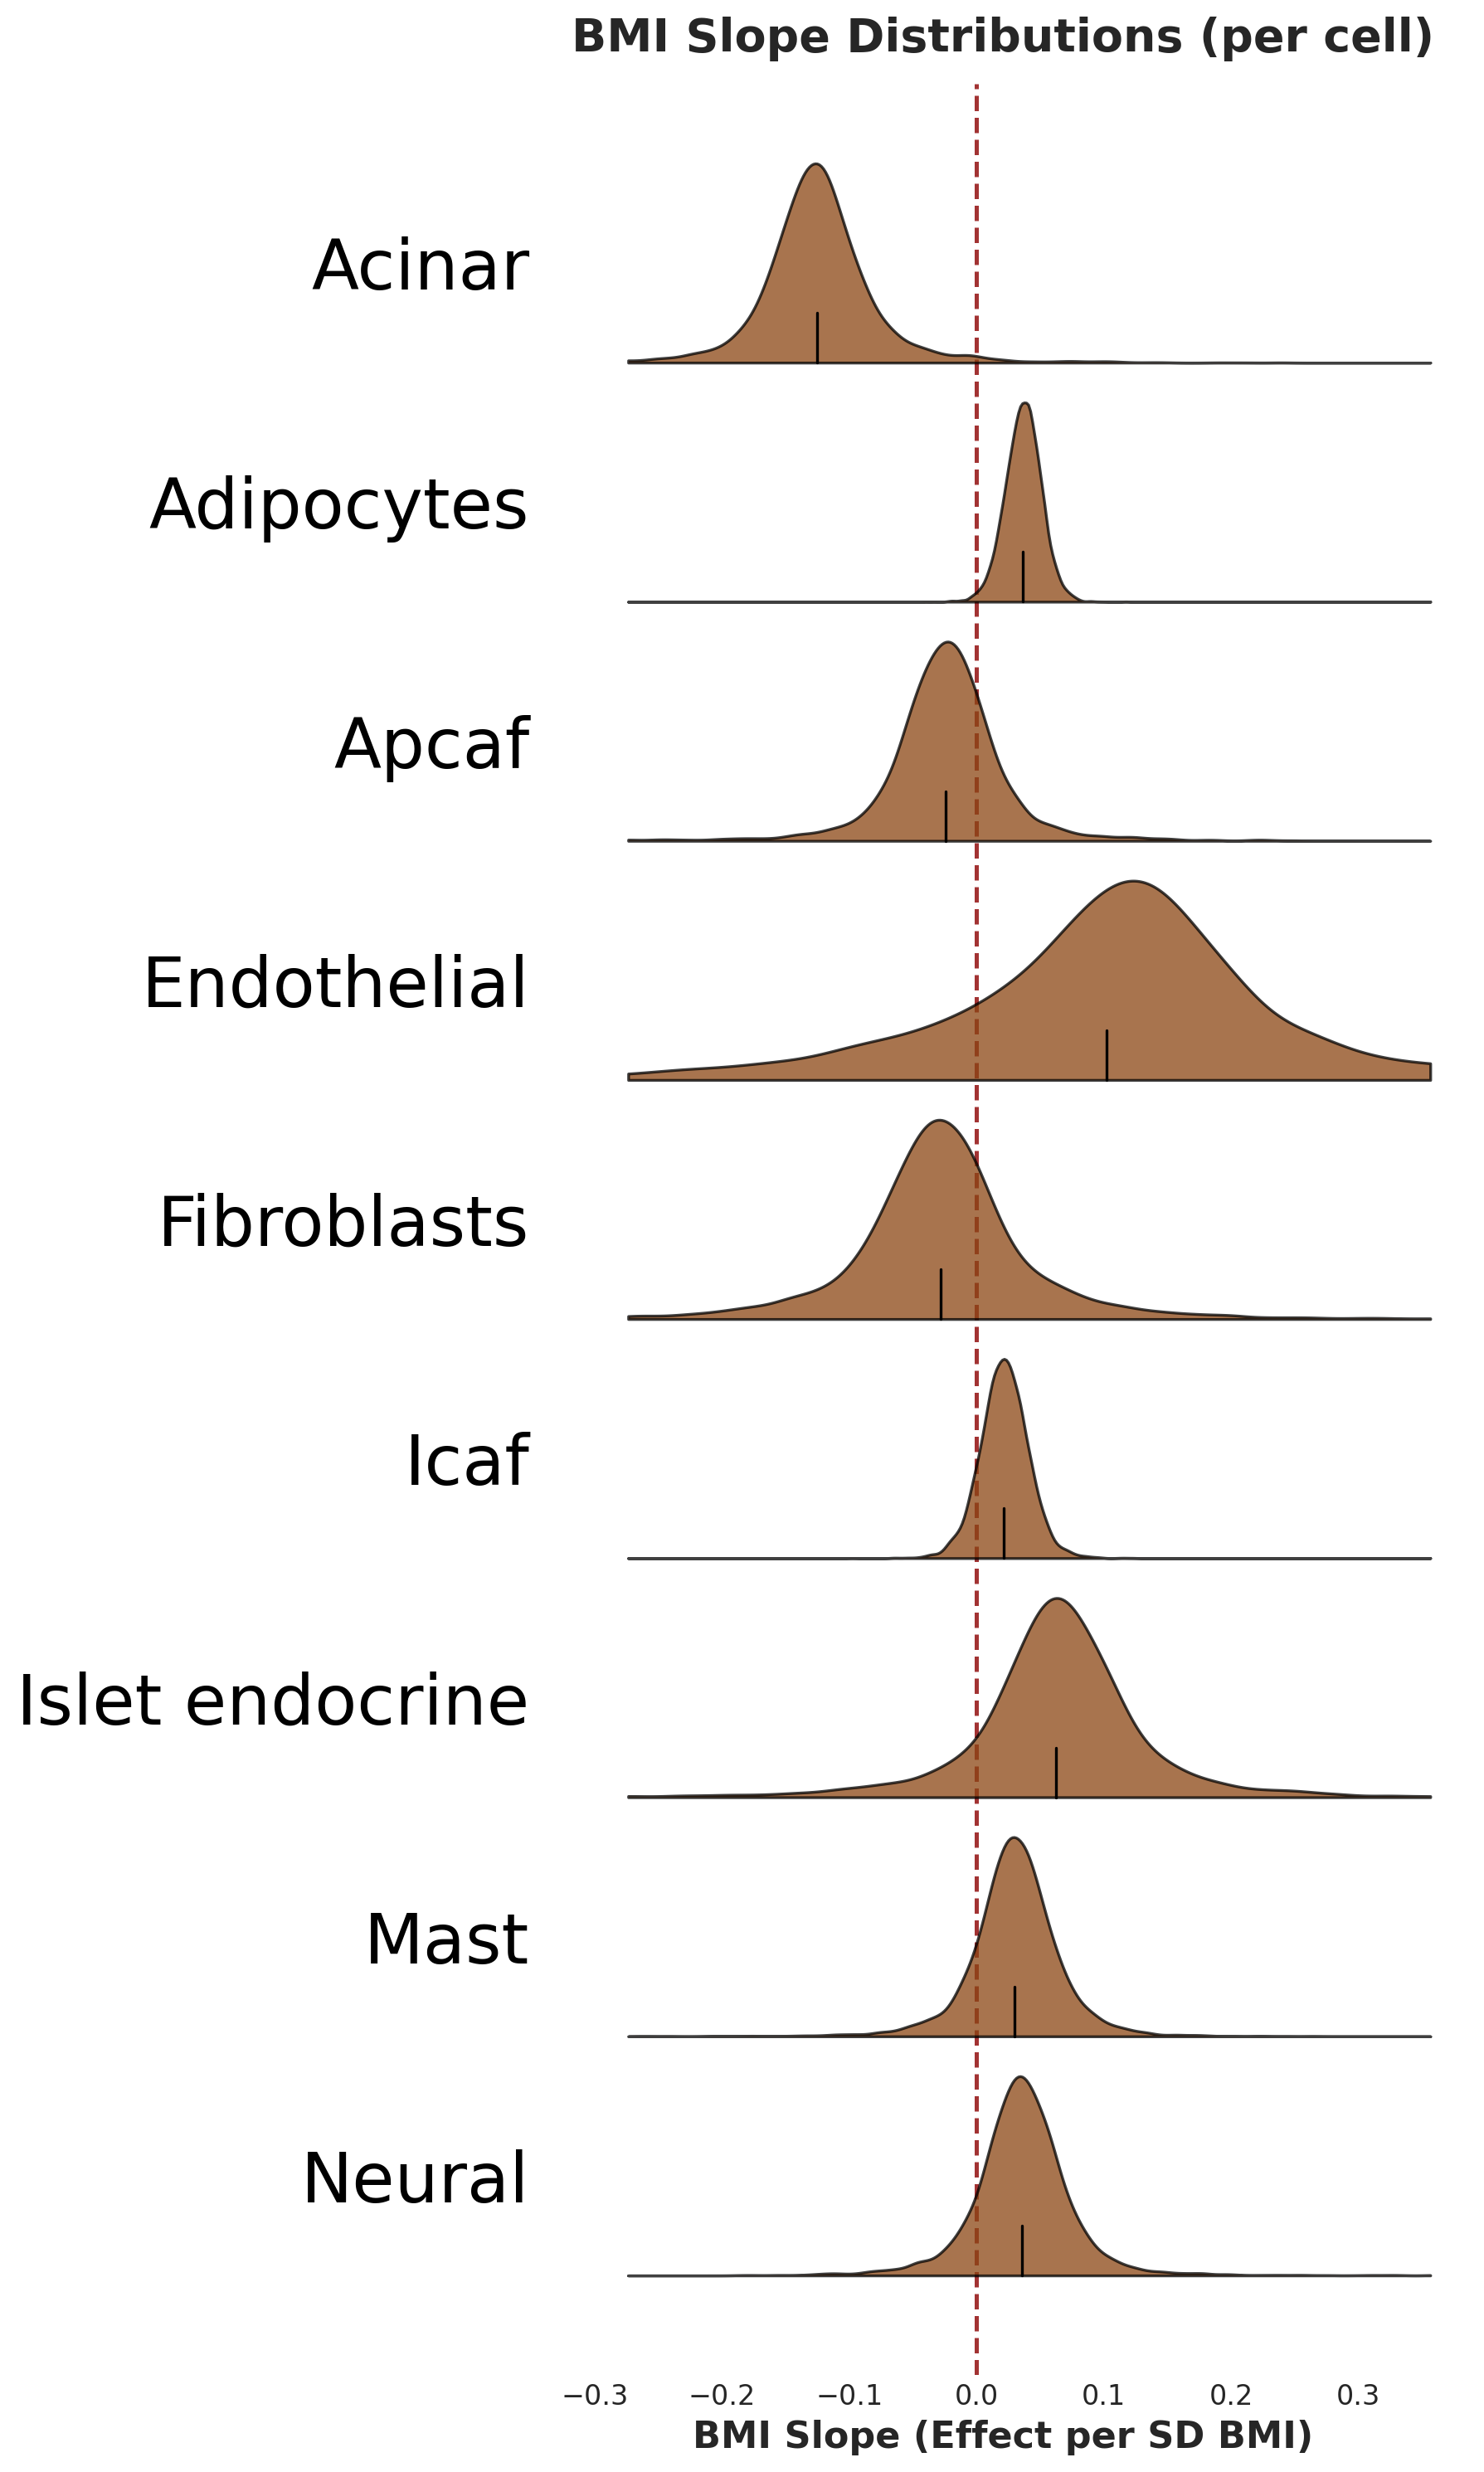

Saved legend: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_nonimmune/continuous_advanced_diagnostics/overlapped_per_cell/legend_bmi_slope_Non-Immune.png
Saved legend SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/overlapped_per_cell/nonimmune/legend_bmi_slope_Non-Immune.svg

PROCESSING: Immune Fine (Continuous BMI Model)
Creating BMI slope ridge plot: Immune Fine
Saved: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_fine/continuous_advanced_diagnostics/overlapped_per_cell/bmi_slope_per_cell_Immune_Fine.png
Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/overlapped_per_cell/immune_fine/bmi_slope_per_cell_Immune_Fine.svg


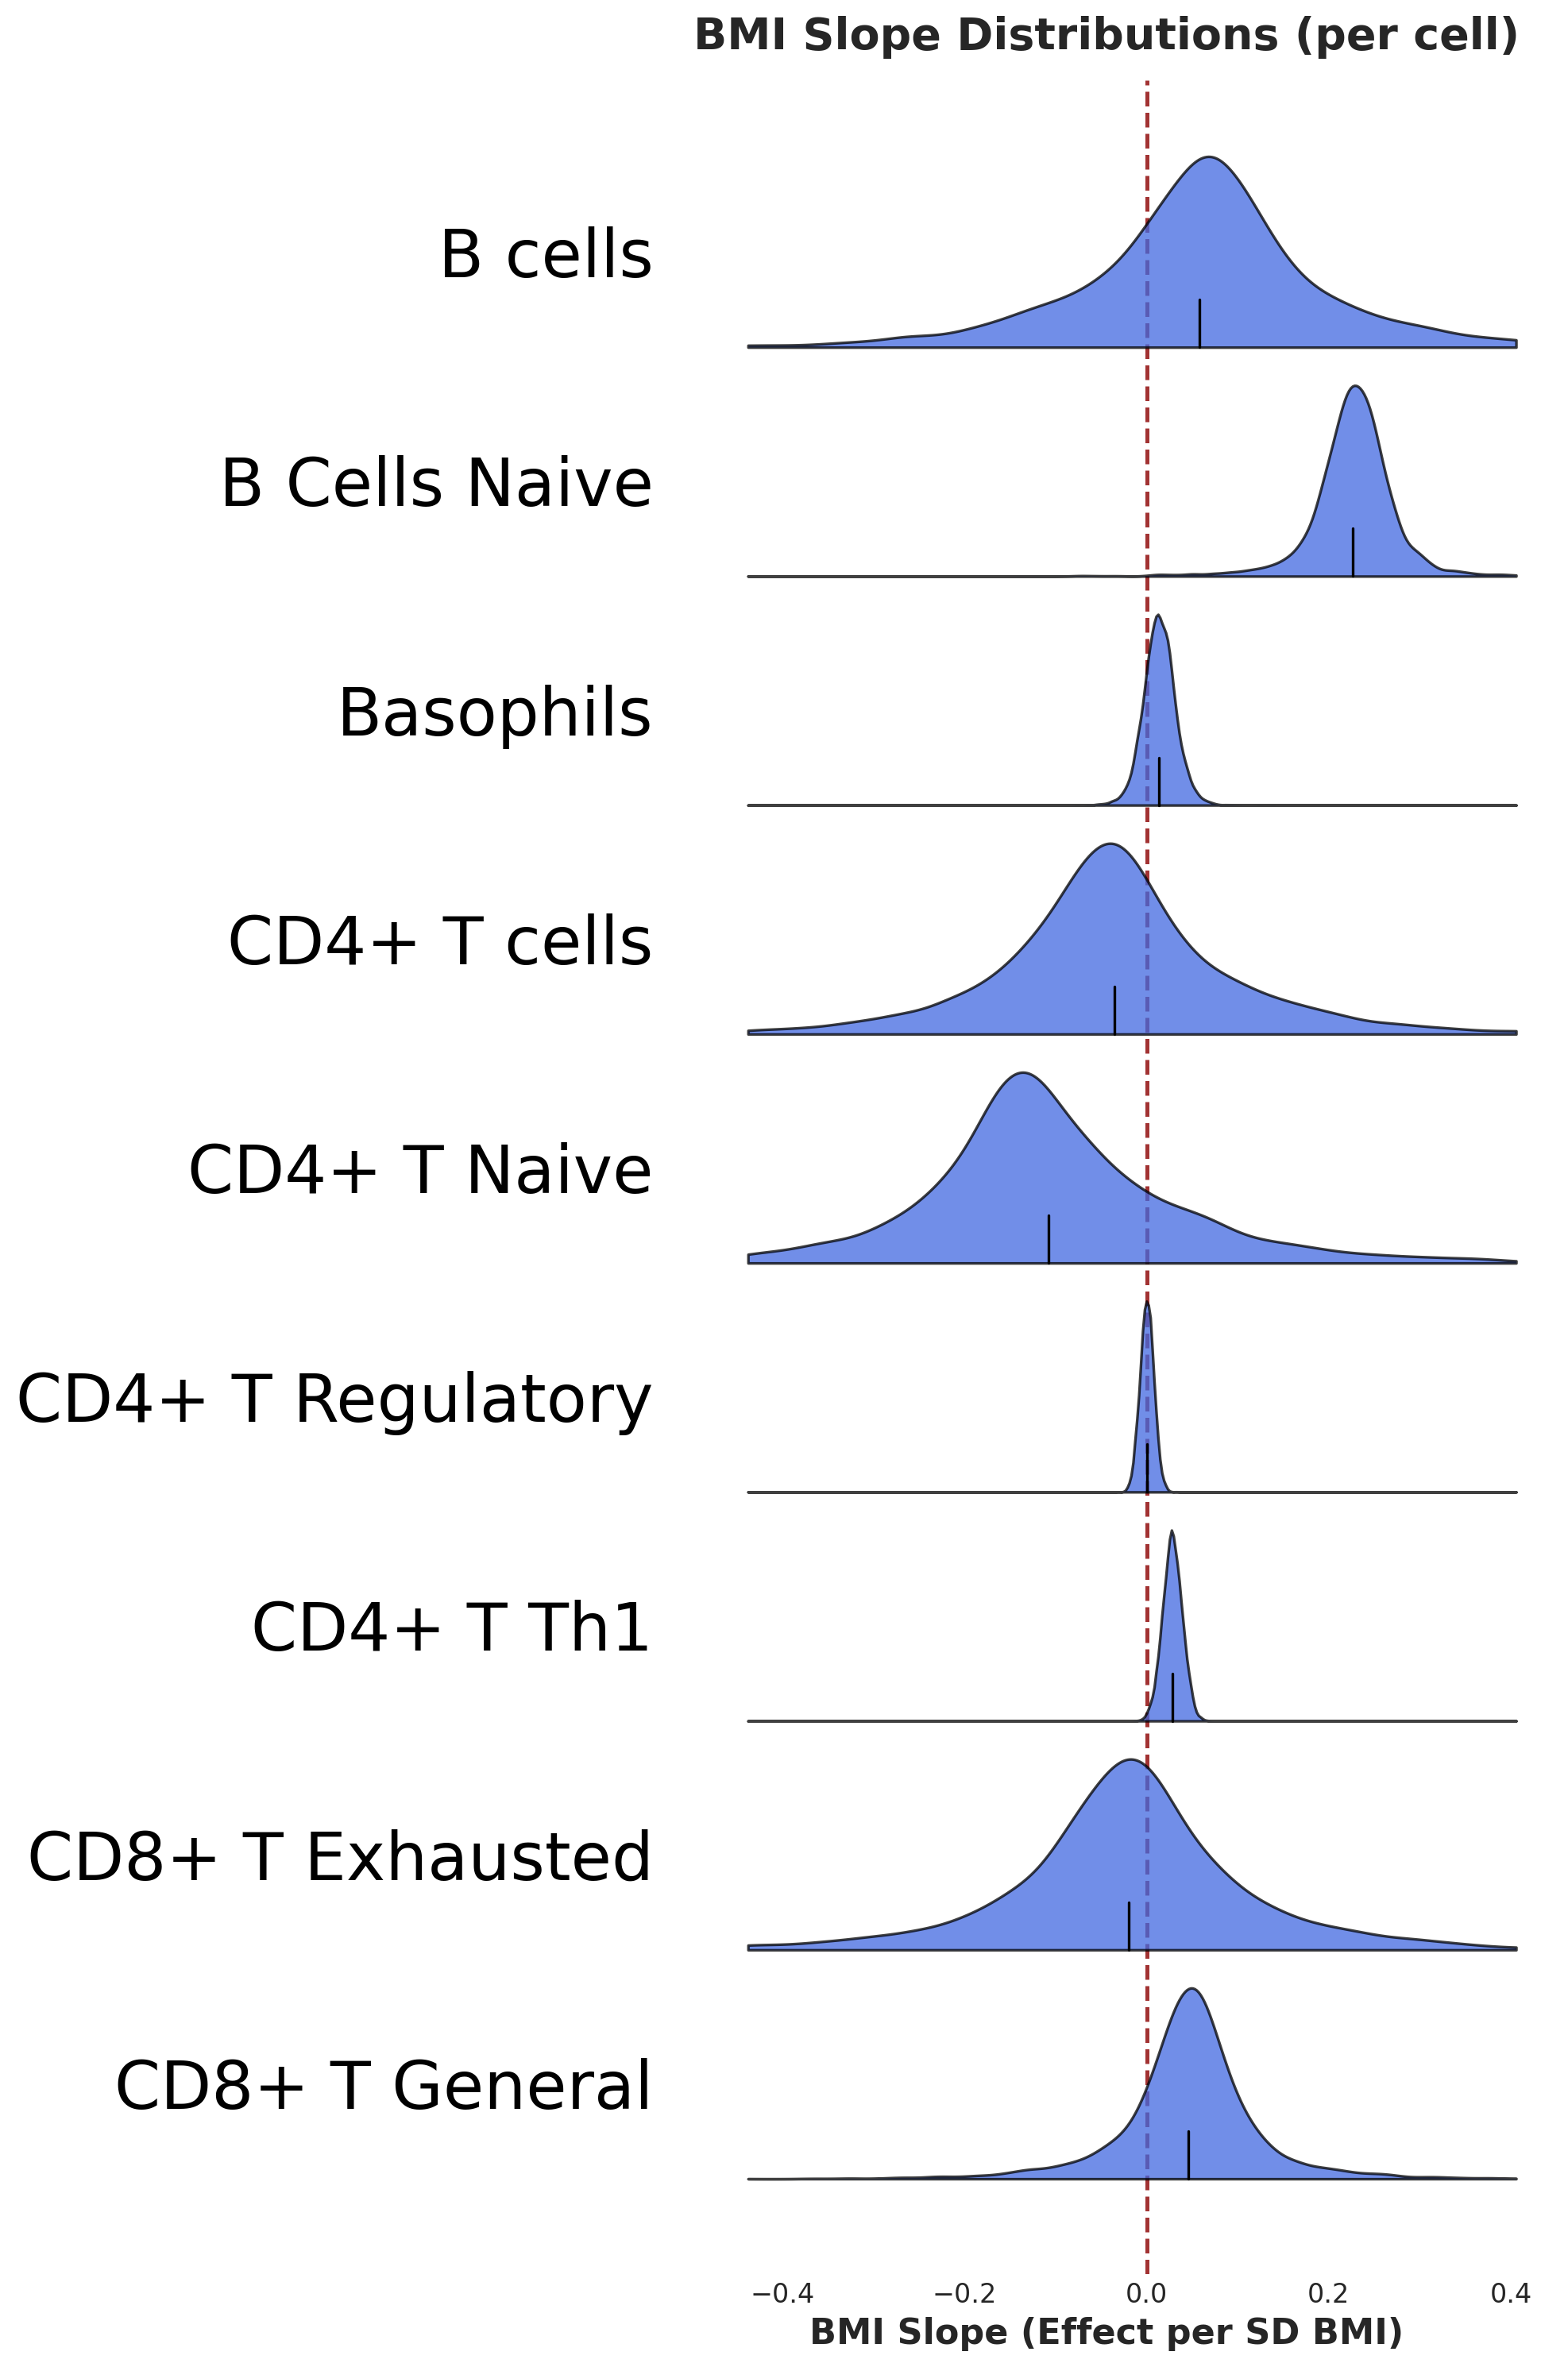

Saved legend: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_fine/continuous_advanced_diagnostics/overlapped_per_cell/legend_bmi_slope_Immune_Fine.png
Saved legend SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/overlapped_per_cell/immune_fine/legend_bmi_slope_Immune_Fine.svg

PROCESSING: Immune Coarse (Continuous BMI Model)
Creating BMI slope ridge plot: Immune Coarse
Saved: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_coarse/continuous_advanced_diagnostics/overlapped_per_cell/bmi_slope_per_cell_Immune_Coarse.png
Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/overlapped_per_cell/immune_coarse/bmi_slope_per_cell_Immune_Coarse.svg


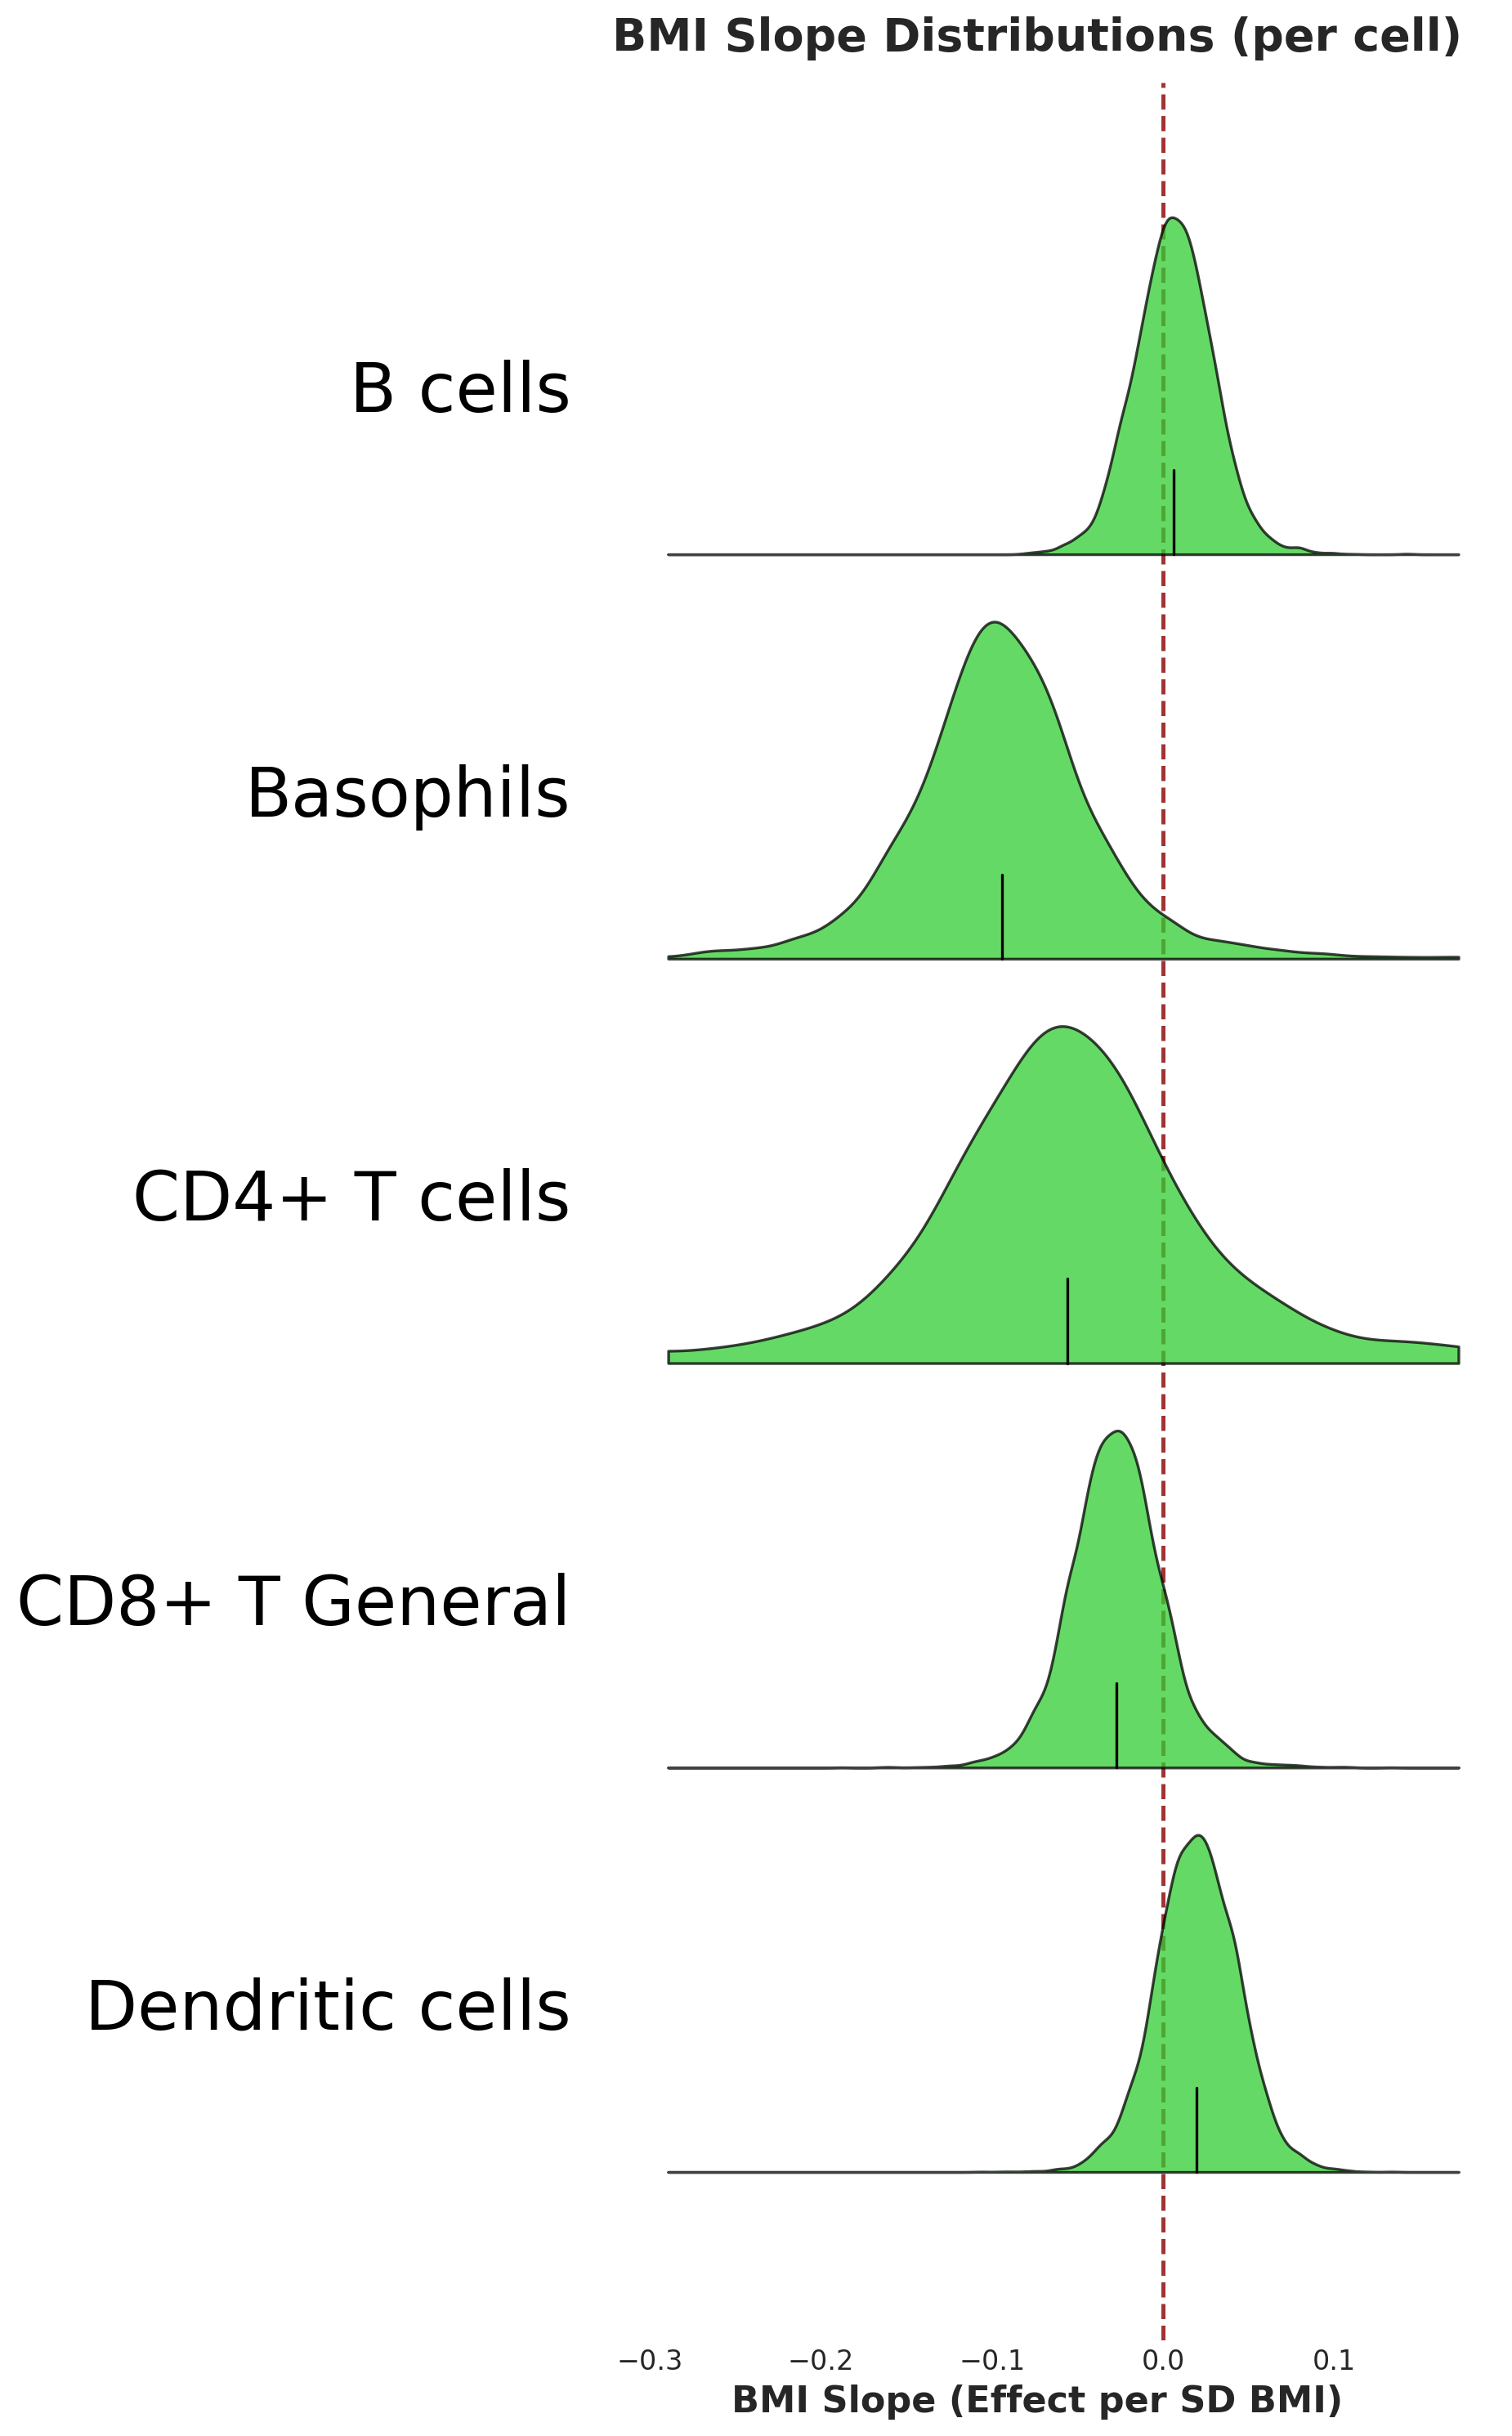

Saved legend: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_coarse/continuous_advanced_diagnostics/overlapped_per_cell/legend_bmi_slope_Immune_Coarse.png
Saved legend SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/overlapped_per_cell/immune_coarse/legend_bmi_slope_Immune_Coarse.svg

All done - Continuous BMI ridge plots complete.


In [ ]:
#!/usr/bin/env python3
"""
ridge_per_cell_continuous_bmi.py - CONTINUOUS BMI VERSION

Creates ridge plots showing posterior BMI slope distributions per cell type.
Each row = one cell type, showing its BMI slope posterior.
Saves main plot (no on-plot legend) and separate legend image.
"""

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import seaborn as sns
import arviz as az
import warnings
warnings.filterwarnings("ignore")

# ---------------------- USER TUNABLES ----------------------
BASE = "/content/drive/MyDrive/new_dysfunction"   # <- set your path

# SVG output configuration
SVG_BASE = f"{BASE}/svg_continuous"
SVG_SUBFOLDER = "overlapped_per_cell"

FIGURE_WIDTH = 8
FIGURE_HEIGHT = 15
FIGURE_DPI = 200

N_TOP = 14                 # None => all cell types
ORDER_MODE = "alphabetical"  # "alphabetical" or "effect"

# KDE / ridge sizing
KDE_POINTS = 400
RIDGE_HEIGHT = 2.2
OVERLAP_SCALE = 1.2       # vertical spacing multiplier (lower -> more overlap)
BANDWIDTH = None           # None => gaussian_kde default, or float

# Colors (continuous BMI version - use compartment color)
COLOR_BMI_SLOPE = "#1f78b4"      # blue (will be overridden by compartment color)
RIDGE_ALPHA = 0.75

# Credible coloring options
CREDIBLE_LABEL_COLOR = "black"   # label color when credible
HIGHLIGHT_RIDGE_IF_CREDIBLE = False  # if True, use CREDIBLE_RIDGE_COLOR for credible ridges
CREDIBLE_RIDGE_COLOR = "#FFD700"    # gold

# Visual tunables
RIDGE_EDGE_WIDTH = 1.2
EDGE_COLOR = "black"
VLINE_WIDTH = 1.8

# Fonts & ticks
CELL_LABEL_SIZE = 14
TITLE_SIZE = 20
AXIS_TITLE_SIZE = 16
X_TICK_SIZE = 12
Y_TICK_SIZE = 30
Y_TICK_COLOR = "black"   # color for non-credible labels

# Label alignment
Y_LABEL_OFFSET = 0.0
FORCE_CENTER_LABELS = True

# Output options
SAVE_PNG = True
SAVE_SVG = True
SHOW_PLOT = True

# Compartments to process
COMPARTMENTS = {
    "nonimmune": {
        "name": "Non-Immune",
        "model_dir": f"{BASE}/bayesian_hierarchical_continuous_nonimmune",
        "color": "#8B4513"
    },
    "immune_fine": {
        "name": "Immune Fine",
        "model_dir": f"{BASE}/bayesian_hierarchical_continuous_immune_fine",
        "color": "#4169E1"
    },
    "immune_coarse": {
        "name": "Immune Coarse",
        "model_dir": f"{BASE}/bayesian_hierarchical_continuous_immune_coarse",
        "color": "#32CD32"
    }
}

# -----------------------------------------------------------

# -------------------- cell aliasing (small canonicalizer) --------------------
ALIASES = {
    "acinar": "Acinar",
    "adipocytes": "Adipocytes",
    "b cells": "B cells",
    "basophils": "Basophils",
    "cd4+ t cells": "CD4+ T cells",
    "cd4 t cells": "CD4+ T cells",
    "cd8+ t cells": "CD8+ T cells",
    "cd8 t cells": "CD8+ T cells",
    "dendritic cells": "Dendritic cells",
    "endothelial": "Endothelial",
    "fibroblasts": "Fibroblasts",
    "islet endocrine": "Islet endocrine",
    "macrophages": "Macrophages",
    "monocytes": "Monocytes",
    "nk cells": "NK cells",
    "neural": "Neural",
    "neutrophils": "Neutrophils",
    "normal ductal": "Normal ductal",
    "pericytes smc": "Pericytes SMC",
    "plasma cells": "Plasma cells",
    "schwann": "Schwann",
    "stellate": "Stellate",
    "t cells": "T cells",
    "tumor classical": "Tumor classical",
    "tumor epithelial": "Tumor epithelial"
}

def canon_cell(x):
    if pd.isna(x):
        return x
    s = str(x).strip().lower()
    s = re.sub(r"[_\-]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    if s in ALIASES:
        return ALIASES[s]
    parts = s.split()
    out = []
    for w in parts:
        if w in ["nk","tam","mdsc","mait","nkt","smc"]:
            out.append(w.upper())
        elif w.startswith("cd") and len(w)>2:
            out.append("CD"+w[2:])
        else:
            out.append(w.capitalize())
    res = " ".join(out)
    res = re.sub(r"\bCD4 T\b","CD4+ T",res)
    res = re.sub(r"\bCD8 T\b","CD8+ T",res)
    return res

# -------------------- helpers --------------------
def load_trace_and_ctmap(model_dir):
    trace_path = os.path.join(model_dir, "posterior_trace_continuous.nc")
    ctmap_path = os.path.join(model_dir, "celltype_mapping.csv")
    if not os.path.exists(trace_path):
        raise FileNotFoundError(f"Trace file missing: {trace_path}")
    trace = az.from_netcdf(trace_path)
    ct_map = None
    if os.path.exists(ctmap_path):
        ct_map = pd.read_csv(ctmap_path)
        for c in ["celltype_name","name","cell_type","display_name"]:
            if c in ct_map.columns:
                ct_map["celltype_name"] = ct_map[c].astype(str)
                break
        if "celltype_name" not in ct_map.columns:
            ct_map["celltype_name"] = ct_map.iloc[:,0].astype(str)
    return trace, ct_map

def extract_posterior_array(trace):
    """Return flattened posterior array shape (samples, n_celltypes) for BMI slope."""
    arr = trace.posterior["celltype_bmi_slope"].values
    # reshape (chains * draws, n_celltypes)
    return arr.reshape(-1, arr.shape[-1])

def choose_indices(post_flat, ct_map, n_top):
    n_ct = post_flat.shape[1]
    means = post_flat.mean(axis=0)
    abs_order = np.argsort(np.abs(means))[::-1]

    if n_top is None or n_top >= n_ct:
        chosen = list(range(n_ct))
    else:
        chosen = list(abs_order[:n_top])

    names = []
    for i in chosen:
        if ct_map is not None and i < len(ct_map):
            raw = ct_map.loc[i,"celltype_name"]
        else:
            raw = f"Cell_{i}"
        names.append(canon_cell(raw))

    if ORDER_MODE == "alphabetical":
        zipped = list(zip(chosen, names))
        zipped_sorted = sorted(zipped, key=lambda t: t[1].lower())
        chosen_sorted = [t[0] for t in zipped_sorted]
        names_sorted = [t[1] for t in zipped_sorted]
        return chosen_sorted, names_sorted

    return chosen, names

# -------------------- plotting core --------------------
def plot_bmi_slope_per_cell(ax, post_bmi, chosen_idx, chosen_names, comp_color):
    """
    For each chosen cell type (in chosen_idx order), plot one KDE ridge
    showing the BMI slope posterior distribution.
    """
    n = len(chosen_idx)
    if n == 0:
        return

    # global x-range across all chosen indices
    all_samps = post_bmi[:, chosen_idx].flatten()
    x_min, x_max = np.percentile(all_samps, [0.5, 99.5])
    x_span = max(1e-6, x_max - x_min)
    xgrid = np.linspace(x_min - 0.03*x_span, x_max + 0.03*x_span, KDE_POINTS)

    # compute HDIs for credible detection per cell
    hdis = np.percentile(post_bmi, [2.5,97.5], axis=0)
    means = post_bmi.mean(axis=0)

    y_pos = 0.0
    y_positions = []      # collect tick positions
    label_colors = []     # collect label colors matching credibility

    for i, (ct_idx, ct_name) in enumerate(zip(chosen_idx, chosen_names)):
        # sample array
        s_bmi = post_bmi[:, ct_idx]

        # density
        try:
            kde = gaussian_kde(s_bmi) if BANDWIDTH is None else gaussian_kde(s_bmi, bw_method=BANDWIDTH)
            d_bmi = kde(xgrid)
            d_bmi = (d_bmi / d_bmi.max()) * RIDGE_HEIGHT
        except:
            d_bmi = np.zeros_like(xgrid)

        # credible detection (HDI excludes 0)
        credible = (hdis[0, ct_idx] > 0) or (hdis[1, ct_idx] < 0)

        # ridge color (optionally highlight credible ridges)
        ridge_color = comp_color if not (HIGHLIGHT_RIDGE_IF_CREDIBLE and credible) else CREDIBLE_RIDGE_COLOR

        # Plot ridge
        ax.fill_between(xgrid, y_pos, y_pos + d_bmi,
                        facecolor=ridge_color, alpha=RIDGE_ALPHA,
                        edgecolor=EDGE_COLOR, linewidth=RIDGE_EDGE_WIDTH,
                        zorder=10 + i)

        # mean marker (vertical tick)
        ax.plot([means[ct_idx], means[ct_idx]],
                [y_pos, y_pos + RIDGE_HEIGHT * 0.25],
                color="black", linewidth=1.2, zorder=200)

        # record tick position and label color
        y_positions.append(y_pos + RIDGE_HEIGHT / 2.0)
        label_colors.append(CREDIBLE_LABEL_COLOR if credible else Y_TICK_COLOR)

        y_pos += RIDGE_HEIGHT * OVERLAP_SCALE

    # zero reference line
    if x_min <= 0 <= x_max:
        ax.axvline(0, color="darkred", linestyle="--", linewidth=VLINE_WIDTH, alpha=0.8, zorder=5)

    # axis limits and styling
    xpad = 0.12 * x_span
    ax.set_xlim(xgrid.min() - xpad, xgrid.max() + 0.05 * x_span)
    ax.set_ylim(-RIDGE_HEIGHT * 0.5, y_pos + RIDGE_HEIGHT * 0.2)

    # set real yticks & labels
    ax.set_yticks(y_positions)
    ax.set_yticklabels(chosen_names, fontsize=Y_TICK_SIZE)
    # color the tick labels by credibility
    for tl, col in zip(ax.get_yticklabels(), label_colors):
        tl.set_color(col)

    ax.tick_params(axis="x", labelsize=X_TICK_SIZE)
    # remove left/right/top spines
    for s in ("left","right","top"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_linewidth(1.5)

# -------------------- wrapper for one compartment --------------------
def create_bmi_slope_ridge_plot(trace, ct_map, comp_config, out_dir, svg_out_dir):
    """
    Create a ridge plot where each row shows the BMI slope posterior for one cell type.
    Saves the main plot WITHOUT an on-plot legend, and ALSO saves a separate legend image.
    """
    print(f"Creating BMI slope ridge plot: {comp_config['name']}")

    # extract flat array for BMI slope
    post_bmi = extract_posterior_array(trace)

    chosen_idx, chosen_names = choose_indices(post_bmi, ct_map, N_TOP)

    # For plotting bottom->top we reverse:
    chosen_idx = chosen_idx[::-1]
    chosen_names = chosen_names[::-1]

    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT), dpi=FIGURE_DPI)
    fig.patch.set_facecolor("white"); ax.set_facecolor("white")

    plot_bmi_slope_per_cell(ax, post_bmi, chosen_idx, chosen_names, comp_config["color"])

    ax.set_title(f"BMI Slope Distributions (per cell)", fontsize=TITLE_SIZE, fontweight="bold", pad=14)
    ax.set_xlabel("BMI Slope (Effect per SD BMI)", fontsize=AXIS_TITLE_SIZE, fontweight="bold")

    # --- build legend handle (but DO NOT display on main ax) ---
    from matplotlib.patches import Patch
    legend_handles = [
        Patch(facecolor=comp_config["color"], edgecolor="black", alpha=RIDGE_ALPHA,
              label="BMI Slope Posterior")
    ]

    # Save main figure (without legend) -> ensure left margin for labels
    plt.tight_layout()
    # enlarge left margin so y-labels don't get cut off
    plt.subplots_adjust(left=0.28)

    os.makedirs(out_dir, exist_ok=True)
    base_fname = f"bmi_slope_per_cell_{comp_config['name'].replace(' ','_')}"

    # Save PNG
    if SAVE_PNG:
        fname = os.path.join(out_dir, base_fname + ".png")
        plt.savefig(fname, dpi=FIGURE_DPI, bbox_inches="tight", facecolor="white")
        print("Saved:", fname)

    # Save SVG
    if SAVE_SVG:
        os.makedirs(svg_out_dir, exist_ok=True)
        svg_fname = os.path.join(svg_out_dir, base_fname + ".svg")
        plt.savefig(svg_fname, format='svg', bbox_inches="tight", facecolor="white")
        print("Saved SVG:", svg_fname)

    if SHOW_PLOT:
        plt.show()
    plt.close(fig)

    # --- create and save a separate legend figure ---
    try:
        legend_fig = plt.figure(figsize=(3,0.8), dpi=FIGURE_DPI)
        legend_ax = legend_fig.add_subplot(111)
        legend_ax.axis("off")
        # place legend centrally
        legend = legend_ax.legend(handles=legend_handles, loc="center", ncol=1, frameon=False, fontsize=12)

        base_legend_fname = f"legend_bmi_slope_{comp_config['name'].replace(' ','_')}"

        # Save PNG legend
        if SAVE_PNG:
            legend_path = os.path.join(out_dir, base_legend_fname + ".png")
            legend_fig.savefig(legend_path, bbox_inches="tight", pad_inches=0.1, facecolor="white")
            print("Saved legend:", legend_path)

        # Save SVG legend
        if SAVE_SVG:
            svg_legend_path = os.path.join(svg_out_dir, base_legend_fname + ".svg")
            legend_fig.savefig(svg_legend_path, format='svg', bbox_inches="tight", pad_inches=0.1, facecolor="white")
            print("Saved legend SVG:", svg_legend_path)

        plt.close(legend_fig)
    except Exception as e:
        print("Warning: failed to save separate legend:", e)

# -------------------- runner --------------------
def run_for_compartment(key, cfg):
    print("\n" + "="*60)
    print("PROCESSING:", cfg["name"], "(Continuous BMI Model)")
    print("="*60)
    model_dir = cfg["model_dir"]
    out_dir = os.path.join(model_dir, "continuous_advanced_diagnostics", "overlapped_per_cell")
    os.makedirs(out_dir, exist_ok=True)

    # Create SVG output directory
    svg_out_dir = os.path.join(SVG_BASE, SVG_SUBFOLDER, key)
    os.makedirs(svg_out_dir, exist_ok=True)

    trace, ct_map = load_trace_and_ctmap(model_dir)

    # create the BMI slope ridge plot
    try:
        create_bmi_slope_ridge_plot(trace, ct_map, cfg, out_dir, svg_out_dir)
    except Exception as e:
        print("Error creating BMI slope ridge plot:", e)

    return trace, ct_map

def main():
    all_data = {}
    for k, cfg in COMPARTMENTS.items():
        try:
            trace, ct_map = run_for_compartment(k, cfg)
            all_data[k] = {"trace": trace, "ct_map": ct_map, "config": cfg}
        except Exception as e:
            print("Error:", e)

    print("\nAll done - Continuous BMI ridge plots complete.")

if __name__ == "__main__":
    main()